In [3]:
#
# model_cnn.py
#
# Train the AlexNet-inspired CNN
#
# Copyright (c) Microsoft Corporation. All rights reserved.
# Licensed under the MIT License.
#

"""
Highly recommend following this guide:
https://www.tensorflow.org/install/pip#windows_1

"""


#%% Imports

from sklearn.model_selection import train_test_split
import csv
import numpy as np
import matplotlib.pyplot as plt

# Keras imports
from keras import optimizers
from keras.models import  Sequential
from keras.layers import Dense, Dropout, Flatten, BatchNormalization
from keras.layers.convolutional import Conv2D, MaxPooling2D
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc
import os
import gc
import traceback

import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))



Num GPUs Available:  1


In [4]:
"""
Step 1 : Enable Dynamic Memory Allocation

In Jupyter Notebook, restart the kernel (Kernel -> Restart). 
The previous model remains in the memory until the Kernel is restarted, so rerunning the Notebook cells without restarting the kernel may lead to a false Out Of Memory error.

By default, Tensorflow statically allocates the memory in the GPU for the model. 
Larger models can be built when allowing Tensorflow to dynamically allocate the memory.

To enable dynamic memory allocation, run the following commands at the start of the session :
https://www.linkedin.com/pulse/solving-out-memory-oom-errors-keras-tensorflow-running-wayne-cheng
"""

from tensorflow.compat.v1 import ConfigProto
from tensorflow.compat.v1 import InteractiveSession
config = ConfigProto()
config.gpu_options.allow_growth = True
#config.gpu_options.per_process_gpu_memory_fraction = 0.7
session = InteractiveSession(config=config)

#https://github.com/tensorflow/tensorflow/issues/52086
tf.compat.v1.disable_eager_execution()



gpus = tf.config.list_physical_devices('GPU')
if gpus:
    # Restrict TensorFlow to only allocate 1GB of memory on the first GPU
    try:
        tf.config.set_logical_device_configuration(
            gpus[0],
            [tf.config.LogicalDeviceConfiguration(memory_limit=1024)])
        logical_gpus = tf.config.list_logical_devices('GPU')

        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")

    except RuntimeError as e:
        # Virtual devices must be set before GPUs have been initialized
        print(e)


In [5]:
#%% Path configuration


current_dir = os.path.abspath("D:\\beluga")
data_dir = os.path.join(current_dir, "Data")

model_dir = os.path.join(current_dir,"Model")
#spectrogram_dir = os.path.join(data_dir,"Extracted_Spectrogram")
output_spectrogram_vector_dir = os.path.join(data_dir, "Output_Spectrogram_Vector")

for i in [model_dir, output_spectrogram_vector_dir]:

    if not os.path.exists(i):
        os.makedirs(i)

#we need to specify the "training set name" we want to work with
#e.g. BS1KHZ-n721-x1_BDB-n29859-x1
#for replicability's sake, we will store this in a dict

b_positive_variant_dict = {1:"BS1KHZ-n721-x1_BDB-n29859-x1"}
b_false_variant_dict = {1: "FML237-n157-x1_FS1KHZ-n76-x1_FDB-n9860-x1"}
b_negative_variant_dict = {1: "N-n40673-x1"}




In [6]:
#here you can change which variant you are using
positive_variant = 1
false_variant = 1
negative_variant = 1
model_name = "B{b_var}-F{f_var}-N{n_var}".format(b_var = str(positive_variant), f_var = str(false_variant), n_var = str(negative_variant))
print(model_name)


B1-F1-N1


In [7]:
#%% Step 1: train/validation/test split

ncol, nrow = 300, 300
spectrogram_suffix = "spectrograms_sample_300_300.npy"
csv_suffix = "filenames_sample.csv"

beluga_positive_basepath = os.path.join(output_spectrogram_vector_dir, "_".join(["beluga-positive", b_positive_variant_dict[positive_variant]]))
beluga_false_basepath = os.path.join(output_spectrogram_vector_dir, "_".join(["beluga-false", b_false_variant_dict[false_variant]]))
beluga_negative_basepath = os.path.join(output_spectrogram_vector_dir, os.path.join("_".join(["beluga-negative", b_negative_variant_dict[negative_variant]])))

#print(beluga_positive_basepath, beluga_false_basepath, beluga_negative_basepath)

#get the numpy arrays
print("loading beluga")
spectrograms_B_sample = np.load("-".join([beluga_positive_basepath,spectrogram_suffix]))
print("loading false beluga")
spectrograms_F_sample = np.load("-".join([beluga_false_basepath,spectrogram_suffix]))
print("loading negative beluga")
spectrograms_N_sample = np.load("-".join([beluga_negative_basepath,spectrogram_suffix]))

#get the csv files    
filenames_B_sample = []
filenames_F_sample = []
filenames_N_sample = []


print("loading positive beluga csv")
with open("-".join([beluga_positive_basepath, csv_suffix]), newline='') as f:
    for row in csv.reader(f):
        filenames_B_sample.append(row[0])

print("loading false beluga csv")
with open("-".join([beluga_false_basepath, csv_suffix]), newline='') as f:
    for row in csv.reader(f):
        filenames_F_sample.append(row[0])
print("loading negative beluga csv")
with open("-".join([beluga_negative_basepath, csv_suffix]), newline='') as f:
    for row in csv.reader(f):
        filenames_N_sample.append(row[0])




loading beluga
loading false beluga
loading negative beluga
loading positive beluga csv
loading false beluga csv
loading negative beluga csv


In [10]:
print(len(filenames_B_sample))

30580


In [9]:
spectrograms_B_train_validation, spectrograms_B_test, filenames_B_train_validation, filenames_B_test = train_test_split(spectrograms_B_sample, filenames_B_sample, test_size = 0.3, random_state = 1)
spectrograms_F_train_validation, spectrograms_F_test, filenames_F_train_validation, filenames_F_test = train_test_split(spectrograms_F_sample, filenames_F_sample, test_size = 0.3, random_state = 1)
spectrograms_N_train_validation, spectrograms_N_test, filenames_N_train_validation, filenames_N_test = train_test_split(spectrograms_N_sample, filenames_N_sample, test_size = 0.3, random_state = 1)



In [11]:
spectrograms_train_validation = np.concatenate((spectrograms_B_train_validation, spectrograms_F_train_validation, spectrograms_N_train_validation), axis=0)
labels_train_validation = np.array([1] * len(spectrograms_B_train_validation) + [0] * len(spectrograms_F_train_validation) + [0] * len(spectrograms_N_train_validation))

X_train, X_validation, y_train, y_validation = train_test_split(spectrograms_train_validation, labels_train_validation, test_size = 0.3, random_state = 1)

X_train = X_train / 255.0
X_validation = X_validation / 255.0

print(X_train.shape)   
print(X_validation.shape)   
print(spectrograms_B_test.shape)   
print(spectrograms_F_test.shape)   
print(spectrograms_N_test.shape)
#%% Step 2: build model

def model_cnn(input_shape):
    model = Sequential()

    model.add(Conv2D(128, input_shape=input_shape, kernel_size = (3,3), strides=(2,3), activation='relu', padding='same'))
    model.add(MaxPooling2D(3, strides=(1,2)))
    model.add(BatchNormalization())

    model.add(Conv2D(128, kernel_size = (3,3), strides=(1,1), activation='relu', padding='same'))
    model.add(MaxPooling2D(3, strides=2))
    model.add(BatchNormalization())

    model.add(Conv2D(192, 3, strides=1, activation='relu', padding='same'))
    model.add(Conv2D(192, 3, strides=1, activation='relu', padding='same'))
    model.add(Conv2D(128, 3, strides=1, activation='relu', padding='same'))
    model.add(MaxPooling2D(3, strides=(1,2)))
    model.add(BatchNormalization())

    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    return model

model = model_cnn(X_train.shape[1:])
#optimizer = optimizers.SGD(lr=0.001, decay=1e-5, momentum=0.9)

"per https://stackoverflow.com/questions/70568207/attributeerror-module-keras-optimizers-has-no-attribute-adam-i-am-getting"
optimizer = tf.keras.optimizers.Adam(lr=0.0001, decay=1e-7) 
#optimizer = optimizers.adam(lr=0.0001, decay=1e-7)
model.compile(loss='binary_crossentropy',optimizer=optimizer,metrics=['accuracy'])
model.summary()





(39859, 300, 300, 3)
(17083, 300, 300, 3)
(9174, 300, 300, 3)
(3028, 300, 300, 3)
(12202, 300, 300, 3)
Instructions for updating:
Colocations handled automatically by placer.
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 150, 100, 128)     3584      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 148, 49, 128)     0         
 )                                                               
                                                                 
 batch_normalization (BatchN  (None, 148, 49, 128)     512       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 148, 49, 128)      147584    
                                                                 
 max_pooling2

C:\ProgramData\Anaconda3\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:110: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(Adam, self).__init__(name, **kwargs)


In [12]:
#Save some RAM
del filenames_B_sample
del filenames_F_sample
del filenames_N_sample
del spectrograms_B_sample
del spectrograms_F_sample
del spectrograms_N_sample
gc.collect()

40

In [13]:
gc.collect()

20

In [14]:
#es = EarlyStopping(monitor='val_loss', mode='min', verbose=1)  ## early stopping
try:
    model_history = model.fit(X_train, y_train, batch_size = 64, epochs=15, verbose=1, validation_data=(X_validation, y_validation), max_queue_size=2)
except:
    traceback.print_exc()
    



Train on 39859 samples, validate on 17083 samples
Epoch 1/15
39859/39859 [==============================] - ETA: 0s - loss: 0.4012 - accuracy: 0.8335

C:\ProgramData\Anaconda3\lib\site-packages\keras\engine\training_v1.py:2045: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates = self.state_updates


39859/39859 [==============================] - 692s 17ms/sample - loss: 0.4012 - accuracy: 0.8335 - val_loss: 1.1134 - val_accuracy: 0.7492
Epoch 2/15
39859/39859 [==============================] - 691s 17ms/sample - loss: 0.2082 - accuracy: 0.9267 - val_loss: 0.1853 - val_accuracy: 0.9271
Epoch 3/15
39859/39859 [==============================] - 708s 18ms/sample - loss: 0.1662 - accuracy: 0.9424 - val_loss: 0.1443 - val_accuracy: 0.9517
Epoch 4/15
39859/39859 [==============================] - 741s 19ms/sample - loss: 0.1492 - accuracy: 0.9494 - val_loss: 0.1407 - val_accuracy: 0.9507
Epoch 5/15
39859/39859 [==============================] - 646s 16ms/sample - loss: 0.1339 - accuracy: 0.9554 - val_loss: 0.1189 - val_accuracy: 0.9597
Epoch 6/15
39859/39859 [==============================] - 682s 17ms/sample - loss: 0.1192 - accuracy: 0.9601 - val_loss: 0.1069 - val_accuracy: 0.9642
Epoch 7/15
39859/39859 [==============================] - 729s 18ms/sample - loss: 0.1083 - accuracy: 0.9

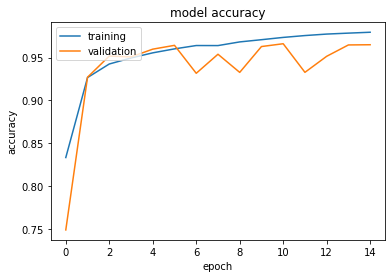

In [15]:
#model.history.history doesn't have acc or val_acc, but does have accuracy and value_accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['training', 'validation'], loc='upper left')
#plt.show()



C:\ProgramData\Anaconda3\lib\site-packages\keras\engine\training_v1.py:2067: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


0.9369958578591672
0.9356010568031704


No handles with labels found to put in legend.


0.9927880675299131
AUC: 0.9802


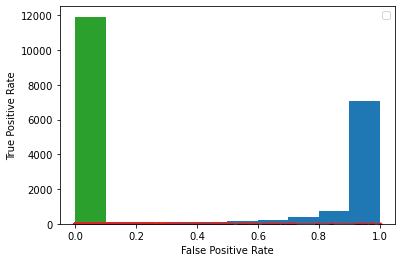

No handles with labels found to put in legend.


Precesion Recall AUC: 0.9926


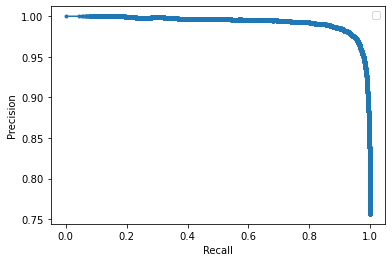

In [16]:
# Save the weights
output_file_name = os.path.join(model_dir, "-".join([model_name,'cnn_weights_all_data.h5']))
model.save_weights(output_file_name)

# Save the model architecture
with open(os.path.join(model_dir, "-".join([model_name,'cnn_architecture_all_data.json'])), 'w') as f:
    f.write(model.to_json())


#%% Step 3: predict on the test set
    
del X_train
del X_validation
del spectrograms_B_train_validation
del spectrograms_F_train_validation
del spectrograms_N_train_validation

spectrograms_B_test_predict = model.predict(spectrograms_B_test / 255.0)
spectrograms_B_test_wrong_predictions = [i for i,v in enumerate(spectrograms_B_test_predict) if v < 0.5]
plt.hist(spectrograms_B_test_predict)
print(1 - len(spectrograms_B_test_wrong_predictions) / len(spectrograms_B_test_predict))

spectrograms_F_test_predict = model.predict(spectrograms_F_test / 255.0)
spectrograms_F_test_wrong_predictions = [i for i,v in enumerate(spectrograms_F_test_predict) if v > 0.5]
plt.hist(spectrograms_F_test_predict)
print(1 - len(spectrograms_F_test_wrong_predictions) / len(spectrograms_F_test_predict))

spectrograms_N_test_predict = model.predict(spectrograms_N_test / 255.0)
spectrograms_N_test_wrong_predictions = [i for i,v in enumerate(spectrograms_N_test_predict) if v > 0.5]
plt.hist(spectrograms_N_test_predict)
print(1 - len(spectrograms_N_test_wrong_predictions) / len(spectrograms_N_test_predict))

tp = len([i for i,v in enumerate(spectrograms_B_test_predict) if v >= 0.5])
fn = len([i for i,v in enumerate(spectrograms_B_test_predict) if v < 0.5])
tn = len([i for i,v in enumerate(spectrograms_F_test_predict) if v < 0.5])
fp = len([i for i,v in enumerate(spectrograms_F_test_predict) if v >= 0.5])
precision = tp / (tp + fp) 
recall = tp / (tp + fn)
accuracy = (tp + tn) / (tp + fp + tn + fn)

y_true = [1] * len(spectrograms_B_test_predict) + [0] * len(spectrograms_F_test_predict)
y_scores = spectrograms_B_test_predict.tolist() + spectrograms_F_test_predict.tolist()

# Calculate ROC and AUC
AUC = roc_auc_score(y_true, y_scores) 
print('AUC: %.4f' % AUC)

# Calculate ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
plt.plot(fpr, tpr, marker='.')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# Calculate precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
precision_recall_auc = auc(recall, precision)
print('Precesion Recall AUC: %.4f' % precision_recall_auc)

# Plot precision-recall curve
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()